In [ ]:
import os

# The cross-encoder model is already cached locally from a prior run --
# skip HF Hub's network version-check on every load (avoids the
# "unauthenticated requests" warning and an unnecessary network call).
os.environ.setdefault("HF_HUB_OFFLINE", "1")

import time
from concurrent.futures import ThreadPoolExecutor, as_completed

import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import eval_lib as ev
from arxiv_rag.es_search import (
    get_es_client,
    index_exists,
    index_to_elasticsearch,
)
from arxiv_rag.indexing import get_index
from arxiv_rag.openai_client import get_client
from arxiv_rag.rerank import get_cross_encoder

# Retrieval Strategy Evaluation

Compares three retrieval strategies for the arXiv RAG pipeline on a sample of
the dataset:

1. **hybrid_rerank** -- NumPy/BM25 hybrid search (RRF) + local cross-encoder rerank (current production default)
2. **hybrid_only** -- NumPy/BM25 hybrid search (RRF) only, no rerank
3. **elasticsearch_rrf** -- Elasticsearch's native RRF retriever (BM25 + kNN), no rerank

For each strategy we measure **retrieval quality** (hit rate / MRR against a
synthetic ground-truth question generated per sampled paper), **answer
relevancy** (LLM-as-a-judge), **token cost**, and **latency** -- then combine
them into a single composite score to pick a winner.

All three strategies share the exact same generation prompt and model; only
the retrieval step differs, so the comparison isolates retrieval quality.

In [ ]:
SAMPLE_SIZE = 200
TOP_K = 5
RANDOM_SEED = 42
# Kept low: the account's gpt-4o-mini rate limit (200k TPM) was getting
# exhausted at MAX_WORKERS=8, since generation + judge calls (~1.5-2k
# tokens each) stack up fast across many threads. 3 keeps sustained
# throughput comfortably under that limit; generate_question /
# generate_answer / judge_relevancy also retry with backoff on 429s.
MAX_WORKERS = 3

In [ ]:
index = get_index()
mo.md(f"Loaded **{len(index.df):,}** papers, embeddings shape `{index.embeddings.shape}`.")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Loaded <strong>10,000</strong> papers, embeddings shape <code>(10000, 1536)</code>.</span></span>

In [ ]:
# Warm up the lazily-constructed singletons (OpenAI client, cross-encoder
# model, ES client) here in the main thread, before any ThreadPoolExecutor
# cell below. get_cross_encoder() in particular loads a PyTorch model via
# HF transformers; racing its first construction across multiple worker
# threads segfaults (native tokenizer/torch init isn't thread-safe).
get_client()
get_cross_encoder()
get_es_client()
mo.md("Warmed up OpenAI client, cross-encoder model, and Elasticsearch client.")

Loading weights: 100%|███████████████████████████| 105/105 [00:00<00:00, 6101.86it/s]


<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Warmed up OpenAI client, cross-encoder model, and Elasticsearch client.</span></span>

## Elasticsearch setup

In [ ]:
try:
    if not index_exists():
        index_to_elasticsearch(index)
        es_message = f"Indexed {len(index.df):,} papers into Elasticsearch."
    else:
        es_message = "Elasticsearch index already present, reusing it."
    es_available = True
except Exception as exc:  # noqa: BLE001
    es_message = f"Elasticsearch unreachable ({exc}); the elasticsearch_rrf strategy will be skipped."
    es_available = False
mo.md(f"**Elasticsearch:** {es_message}")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>Elasticsearch:</strong> Elasticsearch index already present, reusing it.</span></span>

In [ ]:
strategy_names = [name for name in ev.RETRIEVAL_STRATEGIES if name != "elasticsearch_rrf" or es_available]
mo.md(f"Evaluating strategies: **{', '.join(strategy_names)}**")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Evaluating strategies: <strong>hybrid_rerank, hybrid_only, elasticsearch_rrf</strong></span></span>

## Evaluation sample & ground-truth questions

In [ ]:
sample_df = index.df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
mo.md(f"Sampled **{len(sample_df)}** papers (seed={RANDOM_SEED}) as the evaluation set.")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Sampled <strong>200</strong> papers (seed=42) as the evaluation set.</span></span>

In [ ]:
questions_by_id = {}
question_gen_cost = 0.0
with mo.status.progress_bar(total=len(sample_df), title="Generating eval questions") as _bar:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as _pool:
        _futures = {_pool.submit(ev.generate_question, row): row["entry_id"] for _, row in sample_df.iterrows()}
        for _future in as_completed(_futures):
            entry_id = _futures[_future]
            question, usage = _future.result()
            questions_by_id[entry_id] = question
            question_gen_cost += usage.cost
            _bar.update()

eval_df = sample_df.copy()
eval_df["question"] = eval_df["entry_id"].map(questions_by_id)
mo.md(
    f"Generated {len(eval_df)} questions. Question-generation cost: "
    f"**${question_gen_cost:.4f}** (one-time, shared across all strategies)."
)

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Generated 200 questions. Question-generation cost: <strong>$0.0172</strong> (one-time, shared across all strategies).</span></span>

## Running the evaluation

In [ ]:
tasks = [
    (row.entry_id, row.question, strategy_name)
    for row in eval_df.itertuples()
    for strategy_name in strategy_names
]

eval_results = []
eval_start = time.time()
with mo.status.progress_bar(total=len(tasks), title="Running evaluation", subtitle="question x strategy") as _bar:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as _pool:
        _futures = {
            _pool.submit(ev.evaluate_one, index, entry_id, question, strategy_name, TOP_K): (entry_id, strategy_name)
            for entry_id, question, strategy_name in tasks
        }
        for _future in as_completed(_futures):
            eval_results.append(_future.result())
            _bar.update()
eval_elapsed_s = time.time() - eval_start

results_df = pd.DataFrame([r.__dict__ for r in eval_results])
os.makedirs("artifacts", exist_ok=True)
results_df.to_csv("artifacts/eval_results.csv", index=False)

mo.md(f"Ran {len(results_df)} (question x strategy) evaluations in {eval_elapsed_s / 60:.1f} min.")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Ran 600 (question x strategy) evaluations in 13.8 min.</span></span>

## Results

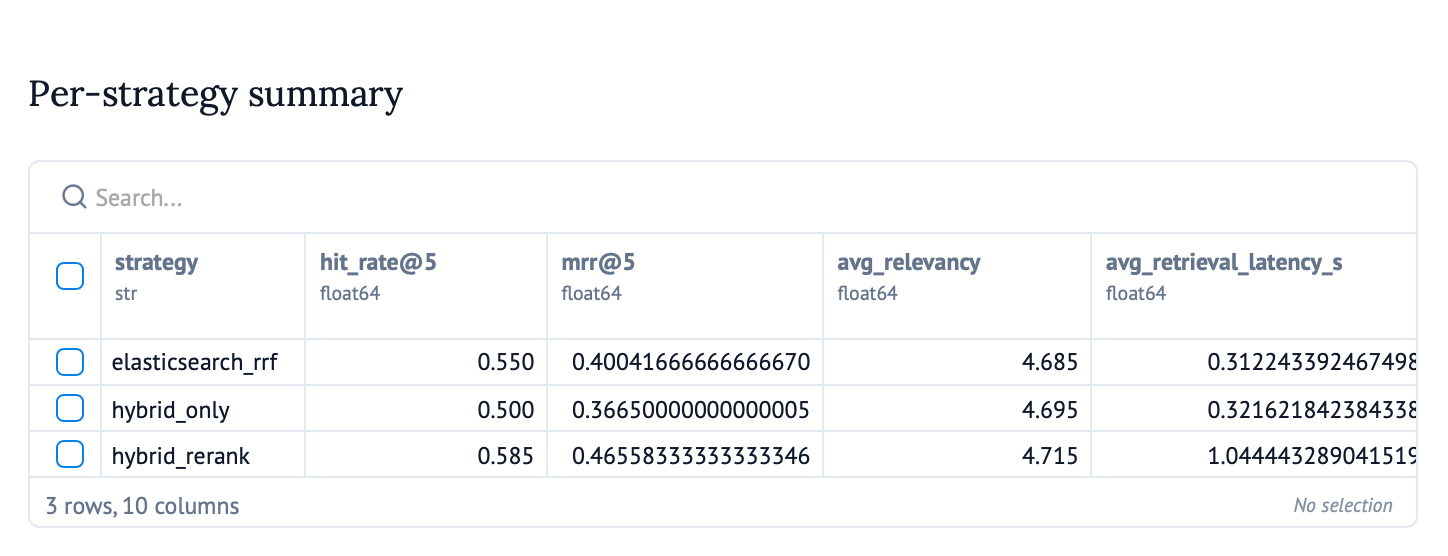

In [ ]:
summary_df = ev.summarize(results_df, TOP_K)
mo.vstack([mo.md("### Per-strategy summary"), mo.ui.table(summary_df)])

In [ ]:
STRATEGY_COLORS = {
    "hybrid_rerank": "#2a78d6",
    "hybrid_only": "#eb6834",
    "elasticsearch_rrf": "#1baf7a",
}
STRATEGY_LABELS = {
    "hybrid_rerank": "Hybrid + Rerank",
    "hybrid_only": "Hybrid only",
    "elasticsearch_rrf": "Elasticsearch RRF",
}

def make_comparison_figure(summary, specs, ncols=2, highlight=None):
    """specs: list of (column, title, value_fmt)."""
    n = len(specs)
    ncols = min(ncols, n)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), facecolor="#fcfcfb")
    axes = np.array(axes).reshape(-1)

    strategies = summary["strategy"].tolist()
    colors = [STRATEGY_COLORS.get(s, "#898781") for s in strategies]
    labels = [STRATEGY_LABELS.get(s, s) for s in strategies]

    for ax, (col, title, fmt) in zip(axes, specs):
        values = summary[col].tolist()
        ax.set_facecolor("#fcfcfb")
        edge_colors = ["#0b0b0b" if s == highlight else "none" for s in strategies]
        edge_widths = [2.5 if s == highlight else 0 for s in strategies]
        bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor=edge_colors, linewidth=edge_widths)
        for bar_, value in zip(bars, values):
            ax.text(
                bar_.get_x() + bar_.get_width() / 2,
                bar_.get_height(),
                fmt.format(value),
                ha="center",
                va="bottom",
                fontsize=9,
                color="#0b0b0b",
            )
        ax.set_title(title, color="#0b0b0b", fontsize=12, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#52514e", labelsize=9)
        ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)
        top = max(values) if values else 1
        ax.set_ylim(0, top * 1.25 if top > 0 else 1)

    for ax in axes[n:]:
        ax.axis("off")

    fig.tight_layout()
    return fig

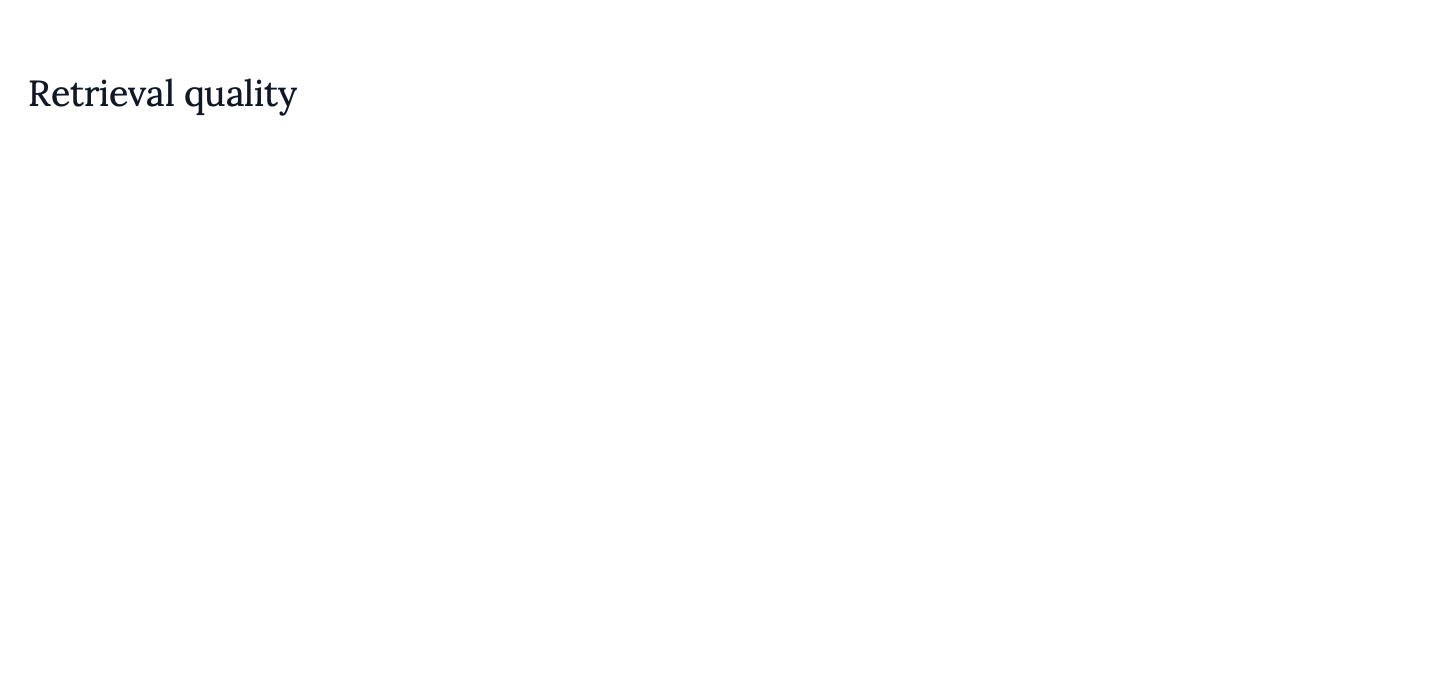

In [ ]:
fig_retrieval = make_comparison_figure(
    summary_df,
    [
        (f"hit_rate@{TOP_K}", f"Hit Rate @ {TOP_K}", "{:.3f}"),
        (f"mrr@{TOP_K}", f"MRR @ {TOP_K}", "{:.3f}"),
    ],
)
fig_retrieval.savefig("artifacts/eval_retrieval_metrics.png", dpi=150)
mo.vstack([mo.md("### Retrieval quality"), fig_retrieval])

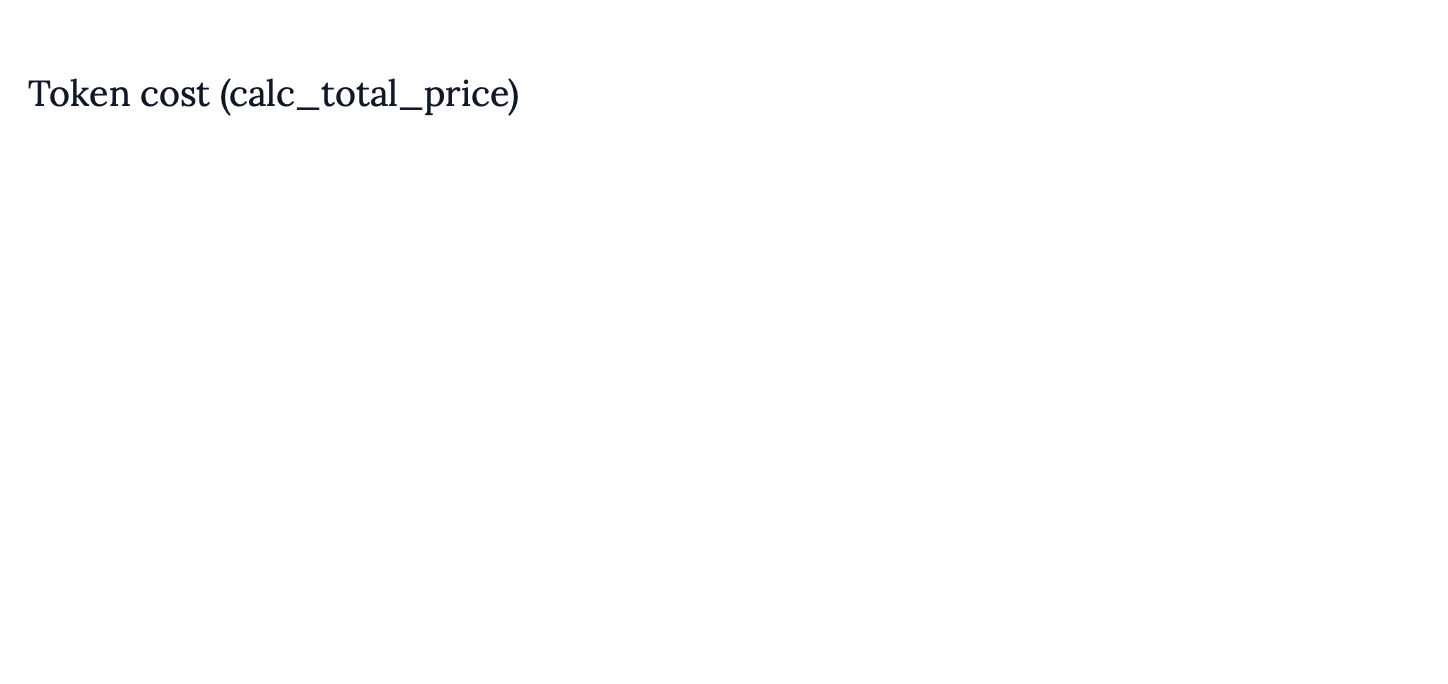

In [ ]:
fig_cost = make_comparison_figure(
    summary_df,
    [
        ("avg_cost_usd", "Avg Cost / Query (USD)", "${:.5f}"),
        (
            "total_cost_usd",
            f"Total Cost, {len(summary_df)} strategies (USD)",
            "${:.4f}",
        ),
    ],
)
fig_cost.savefig("artifacts/eval_cost.png", dpi=150)
mo.vstack([mo.md("### Token cost (calc_total_price)"), fig_cost])

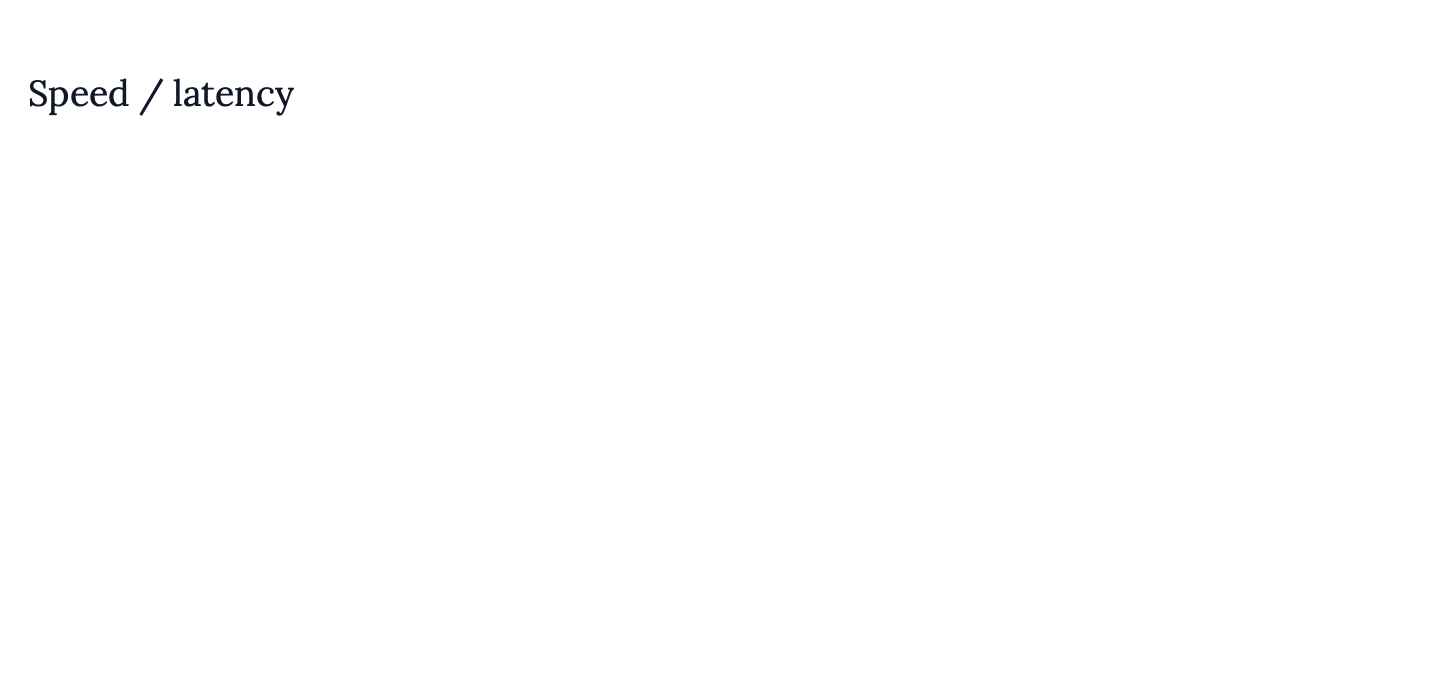

In [ ]:
fig_latency = make_comparison_figure(
    summary_df,
    [
        ("avg_retrieval_latency_s", "Avg Retrieval Latency (s)", "{:.2f}s"),
        ("avg_total_latency_s", "Avg Total Latency (s)", "{:.2f}s"),
    ],
)
fig_latency.savefig("artifacts/eval_latency.png", dpi=150)
mo.vstack([mo.md("### Speed / latency"), fig_latency])

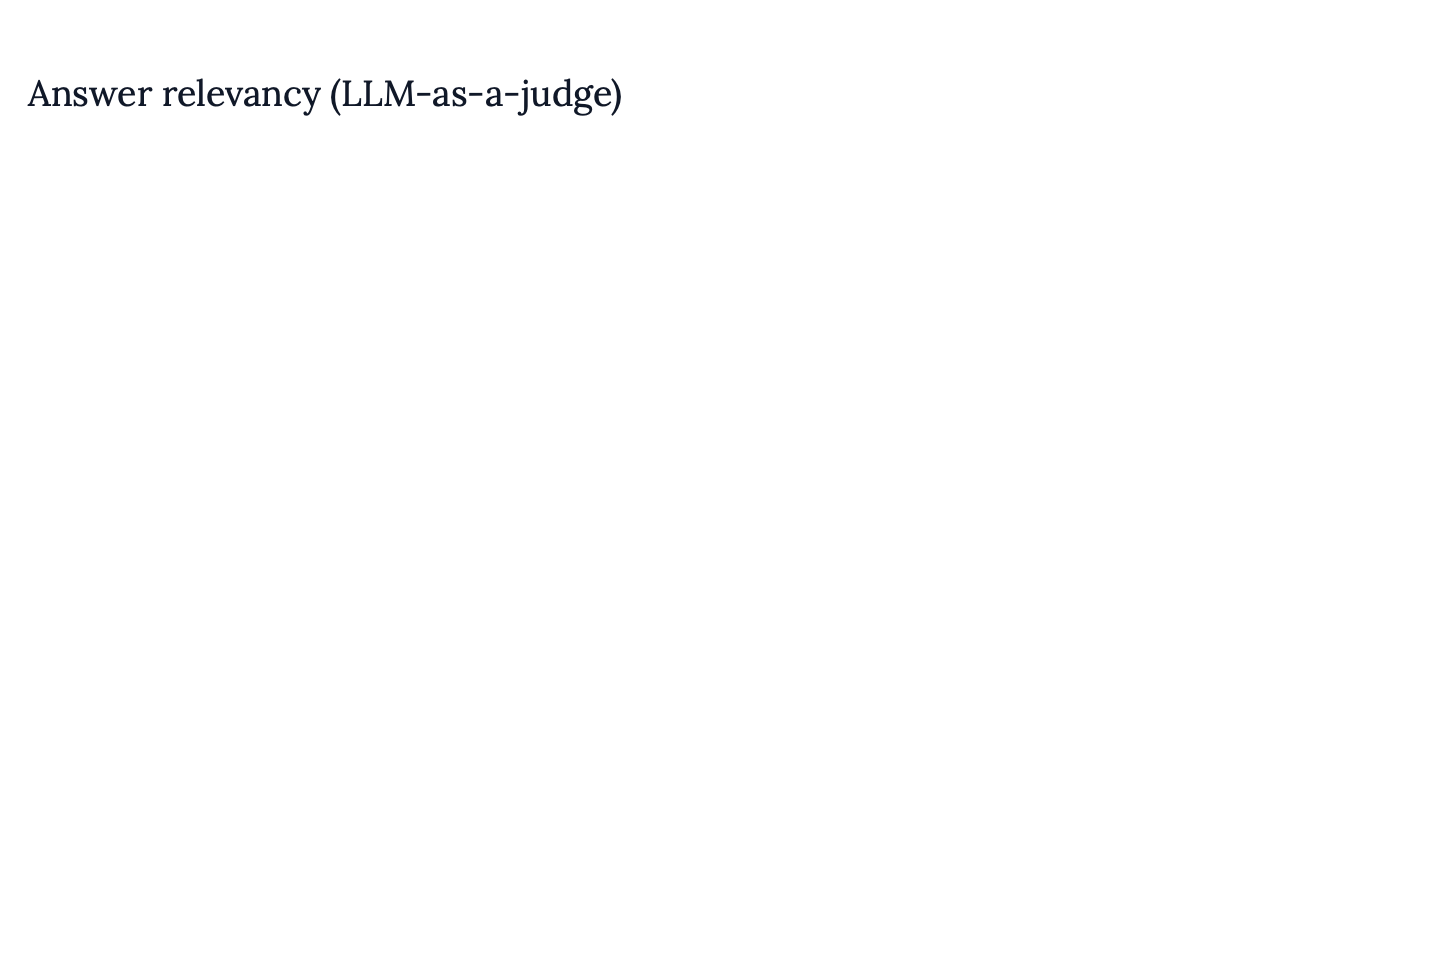

In [ ]:
fig_relevancy = make_comparison_figure(
    summary_df,
    [("avg_relevancy", "Avg Answer Relevancy (LLM judge, 1-5)", "{:.2f}")],
    ncols=1,
)
fig_relevancy.savefig("artifacts/eval_relevancy.png", dpi=150)
mo.vstack([mo.md("### Answer relevancy (LLM-as-a-judge)"), fig_relevancy])

## Statistical reliability

Single point estimates (the table above) can't tell a real quality gap
between strategies apart from run-to-run noise in synthetic question
generation and single-shot LLM-judge scoring. Here we report bootstrap
95% confidence intervals per strategy, and a paired Wilcoxon signed-rank
test between every pair of strategies -- valid because all strategies are
evaluated on the exact same questions, which gives the test much more
power than comparing independent point estimates.

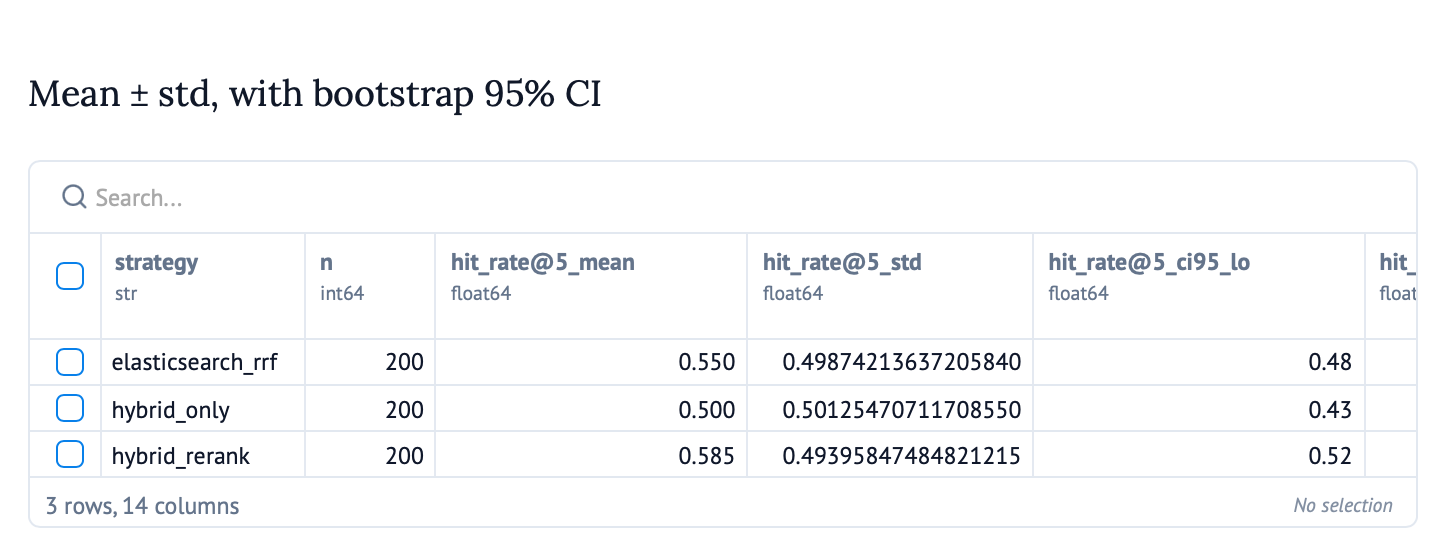

In [ ]:
ci_df = ev.summarize_with_ci(results_df, TOP_K)
mo.vstack([mo.md("### Mean ± std, with bootstrap 95% CI"), mo.ui.table(ci_df)])

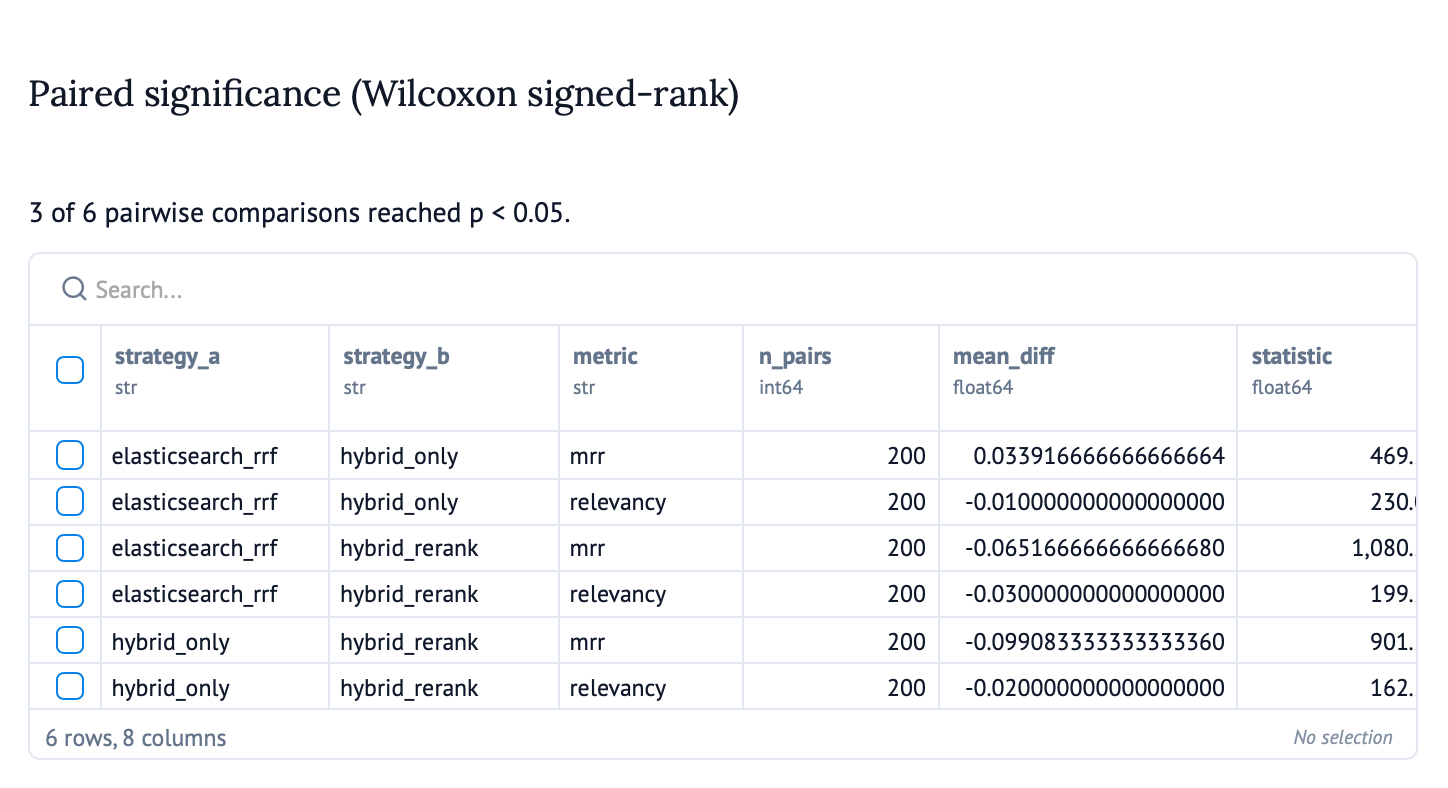

In [ ]:
sig_df = ev.paired_significance(results_df)
n_significant = int(sig_df["significant_p<0.05"].sum())
sig_note = (
    "No pairwise comparison reached p < 0.05 -- treat the ranking below as noise, not a real quality difference."
    if n_significant == 0
    else f"{n_significant} of {len(sig_df)} pairwise comparisons reached p < 0.05."
)
mo.vstack(
    [
        mo.md(f"### Paired significance (Wilcoxon signed-rank)\n\n{sig_note}"),
        mo.ui.table(sig_df),
    ]
)

## Composite score

Combines all four dimensions into one score per strategy (each metric is
min-max normalized across strategies, cost/latency inverted so "lower is
better" scores higher). Adjust the weights to see how the ranking shifts
under different priorities.

In [ ]:
DEFAULT_WEIGHTS = {
    "retrieval": 0.30,
    "relevancy": 0.35,
    "speed": 0.15,
    "cost": 0.20,
}
get_weights, set_weights = mo.state(DEFAULT_WEIGHTS)

In [ ]:
reset_button = mo.ui.button(
    label="Reset to defaults",
    on_click=lambda _: set_weights(DEFAULT_WEIGHTS.copy()),
)

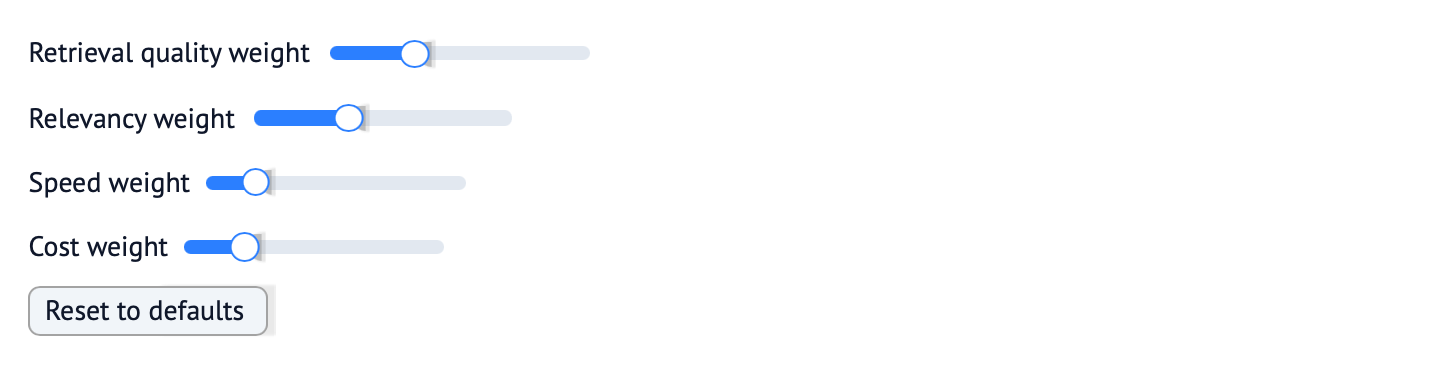

In [ ]:
weight_retrieval = mo.ui.slider(
    0, 1, value=get_weights()["retrieval"], step=0.05,
    label="Retrieval quality weight",
    on_change=lambda v: set_weights({**get_weights(), "retrieval": v}),
)
weight_relevancy = mo.ui.slider(
    0, 1, value=get_weights()["relevancy"], step=0.05,
    label="Relevancy weight",
    on_change=lambda v: set_weights({**get_weights(), "relevancy": v}),
)
weight_speed = mo.ui.slider(
    0, 1, value=get_weights()["speed"], step=0.05,
    label="Speed weight",
    on_change=lambda v: set_weights({**get_weights(), "speed": v}),
)
weight_cost = mo.ui.slider(
    0, 1, value=get_weights()["cost"], step=0.05,
    label="Cost weight",
    on_change=lambda v: set_weights({**get_weights(), "cost": v}),
)

mo.vstack([weight_retrieval, weight_relevancy, weight_speed, weight_cost, reset_button])

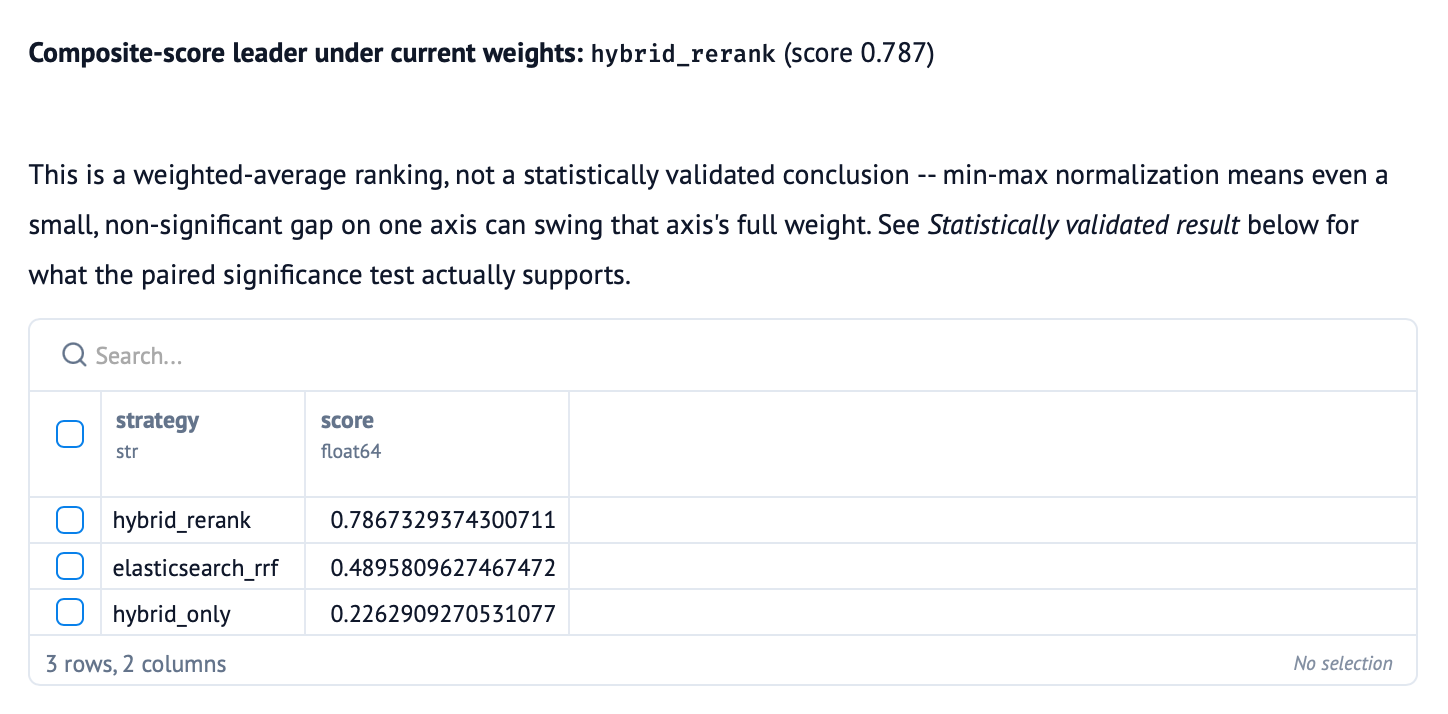

In [ ]:
total_weight = weight_retrieval.value + weight_relevancy.value + weight_speed.value + weight_cost.value
normalized_weights = {
    "retrieval": weight_retrieval.value / total_weight if total_weight else 0,
    "relevancy": weight_relevancy.value / total_weight if total_weight else 0,
    "speed": weight_speed.value / total_weight if total_weight else 0,
    "cost": weight_cost.value / total_weight if total_weight else 0,
}
score_df = ev.compute_composite_score(summary_df, TOP_K, normalized_weights)
winner = score_df.iloc[0]["strategy"]
mo.vstack(
    [
        mo.md(
            f"**Composite-score leader under current weights: `{winner}`** "
            f"(score {score_df.iloc[0]['score']:.3f})\n\n"
            "This is a weighted-average ranking, not a statistically validated "
            "conclusion -- min-max normalization means even a small, non-significant "
            "gap on one axis can swing that axis's full weight. See "
            "*Statistically validated result* below for what the paired "
            "significance test actually supports."
        ),
        mo.ui.table(score_df[["strategy", "score"]]),
    ]
)

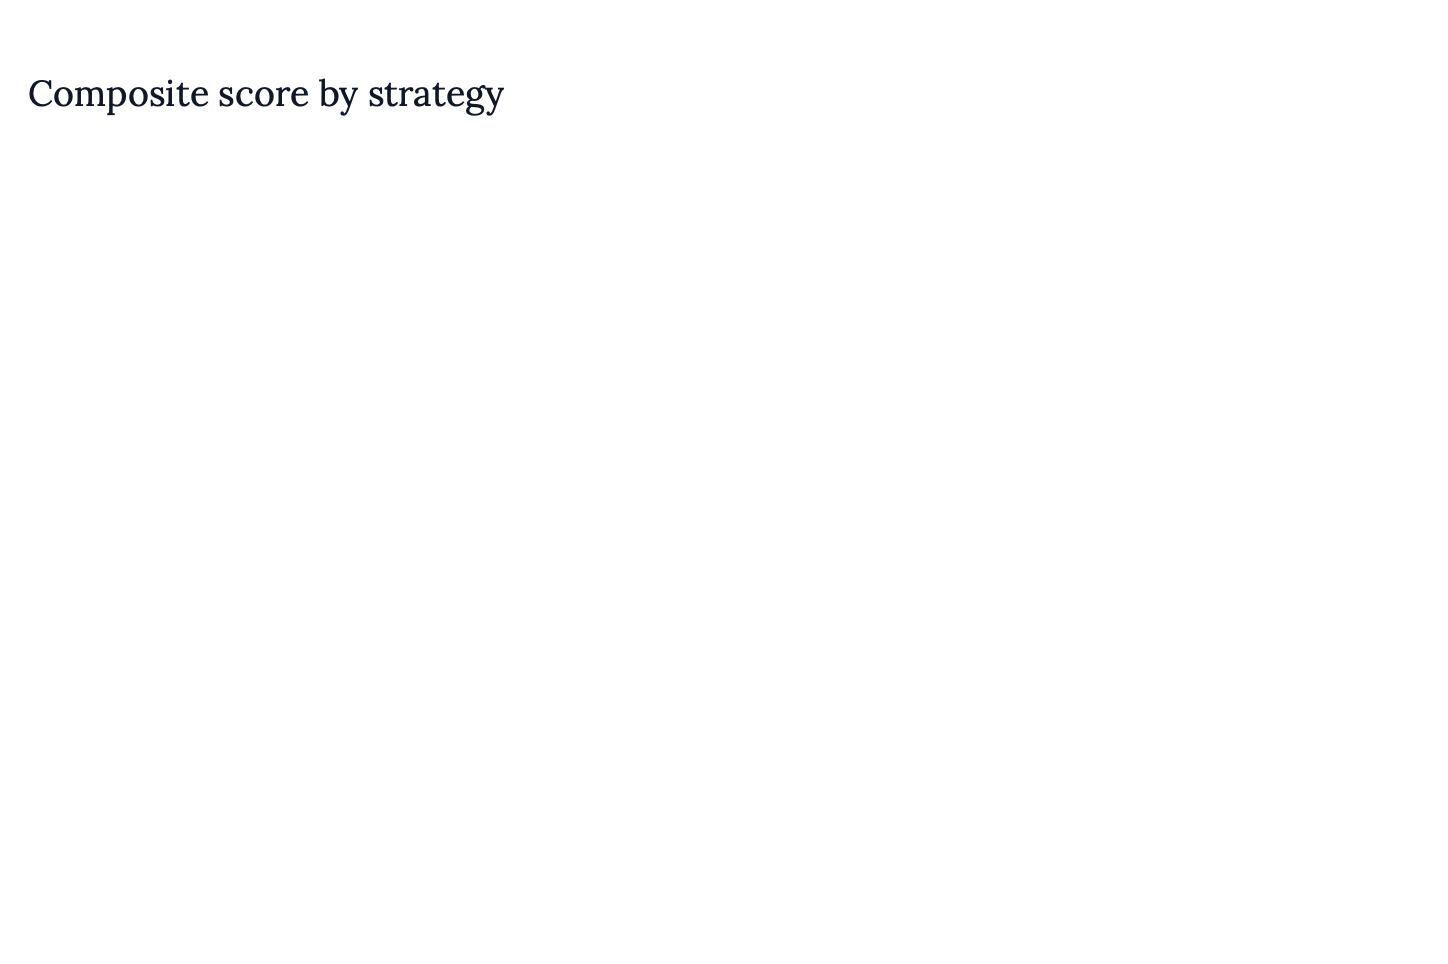

In [ ]:
fig_score = make_comparison_figure(score_df, [("score", "Composite Score", "{:.3f}")], ncols=1, highlight=winner)
fig_score.savefig("artifacts/eval_composite_score.png", dpi=150)
mo.vstack([mo.md("### Composite score by strategy"), fig_score])

In [ ]:
significant_rows = sig_df[sig_df["significant_p<0.05"]]
backing_notes = []
winner_backed_by = []
for _, row in significant_rows.iterrows():
    better, worse = (
        (row["strategy_a"], row["strategy_b"])
        if row["mean_diff"] > 0
        else (row["strategy_b"], row["strategy_a"])
    )
    backing_notes.append(f"`{better}` beats `{worse}` on **{row['metric']}** (p={row['p_value']:.3f})")
    if better == winner:
        winner_backed_by.append(row["metric"])

if not backing_notes:
    significance_summary = (
        "No pairwise comparison reached p < 0.05 on any metric -- none of the "
        "strategies has a statistically validated advantage. Treat all three as "
        "tied on quality and relevancy."
    )
else:
    bullet_list = "\n".join(f"- {note}" for note in backing_notes)
    significance_summary = f"Statistically significant differences found:\n\n{bullet_list}"
    if winner_backed_by:
        significance_summary += (
            f"\n\nThe composite-score leader (`{winner}`) is backed by significant "
            f"wins on: {', '.join(winner_backed_by)}."
        )
    else:
        significance_summary += (
            f"\n\n**Note:** the composite-score leader (`{winner}`) is NOT among the "
            "strategies with a significant win above -- its lead is driven by "
            "non-significant differences that min-max normalization amplified."
        )

mo.md(f"### Statistically validated result\n\n{significance_summary}")

<span class="markdown prose dark:prose-invert contents"><h3 id="statistically-validated-result">Statistically validated result</h3>
<span class="paragraph">Statistically significant differences found:</span>
<ul>
<li><code>elasticsearch_rrf</code> beats <code>hybrid_only</code> on <strong>mrr</strong> (p=0.029)</li>
<li><code>hybrid_rerank</code> beats <code>elasticsearch_rrf</code> on <strong>mrr</strong> (p=0.014)</li>
<li><code>hybrid_rerank</code> beats <code>hybrid_only</code> on <strong>mrr</strong> (p=0.001)</li>
</ul>
<span class="paragraph">The composite-score leader (<code>hybrid_rerank</code>) is backed by significant wins on: mrr, mrr.</span></span>

In [ ]:
if winner_backed_by:
    recommendation = (
        f"**`{winner}`** is both the composite-score leader under the current weights "
        f"and has a statistically significant advantage on {', '.join(winner_backed_by)} -- "
        "the two signals agree, so this is a reasonably confident pick."
    )
else:
    recommendation = (
        f"The composite score currently favors **`{winner}`**, but that ranking is "
        "*not* backed by statistical significance (see above) -- it can flip between "
        "runs as synthetic-question and LLM-judge noise shifts the non-significant "
        "dimensions. Don't treat it as a settled conclusion; re-run the evaluation "
        "and check whether the same strategy keeps winning both the composite score "
        "and the significance test before committing to it in production."
    )

mo.md(f"""
## Conclusion

{recommendation}

Adjust the sliders above to see how the composite-score ranking shifts under
different priorities (e.g. cost-sensitive vs quality-sensitive deployments) --
but the *statistically validated result* section above does not change with
the sliders, since it doesn't depend on the weights.

To make the production app use the composite-score leader, set in `.env`:

```
RETRIEVAL_STRATEGY={winner}
```

`src/arxiv_rag/rag.py` reads `settings.retrieval_strategy` to pick among the
strategies defined in `src/arxiv_rag/strategies.py` -- no code changes needed.
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="conclusion">Conclusion</h2>
<span class="paragraph"><strong><code>hybrid_rerank</code></strong> is both the composite-score leader under the current weights and has a statistically significant advantage on mrr, mrr -- the two signals agree, so this is a reasonably confident pick.</span>
<span class="paragraph">Adjust the sliders above to see how the composite-score ranking shifts under
different priorities (e.g. cost-sensitive vs quality-sensitive deployments) --
but the <em>statistically validated result</em> section above does not change with
the sliders, since it doesn't depend on the weights.</span>
<span class="paragraph">To make the production app use the composite-score leader, set in <code>.env</code>:</span>
<div class="language-scdoc codehilite"><pre><span></span><code>RETRIEVAL_STRATEGY=hybrid_rerank
</code></pre></div>
<span class="paragraph"><code>src/arxiv_rag/rag.py</code> reads <code>settings.retrieval_strategy</code> to pick among the
strategies defined in <code>src/arxiv_rag/strategies.py</code> -- no code changes needed.</span></span>